In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family']    = 'sans-serif'
sns.set_palette('husl')

con = duckdb.connect('../data/processed/ecommerce.duckdb')
con.execute("""
    CREATE VIEW IF NOT EXISTS ecommerce_clean AS
    SELECT * FROM read_parquet('../data/processed/ecommerce_clean.parquet')
""")

print("Ready for EDA!")

Ready for EDA!


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

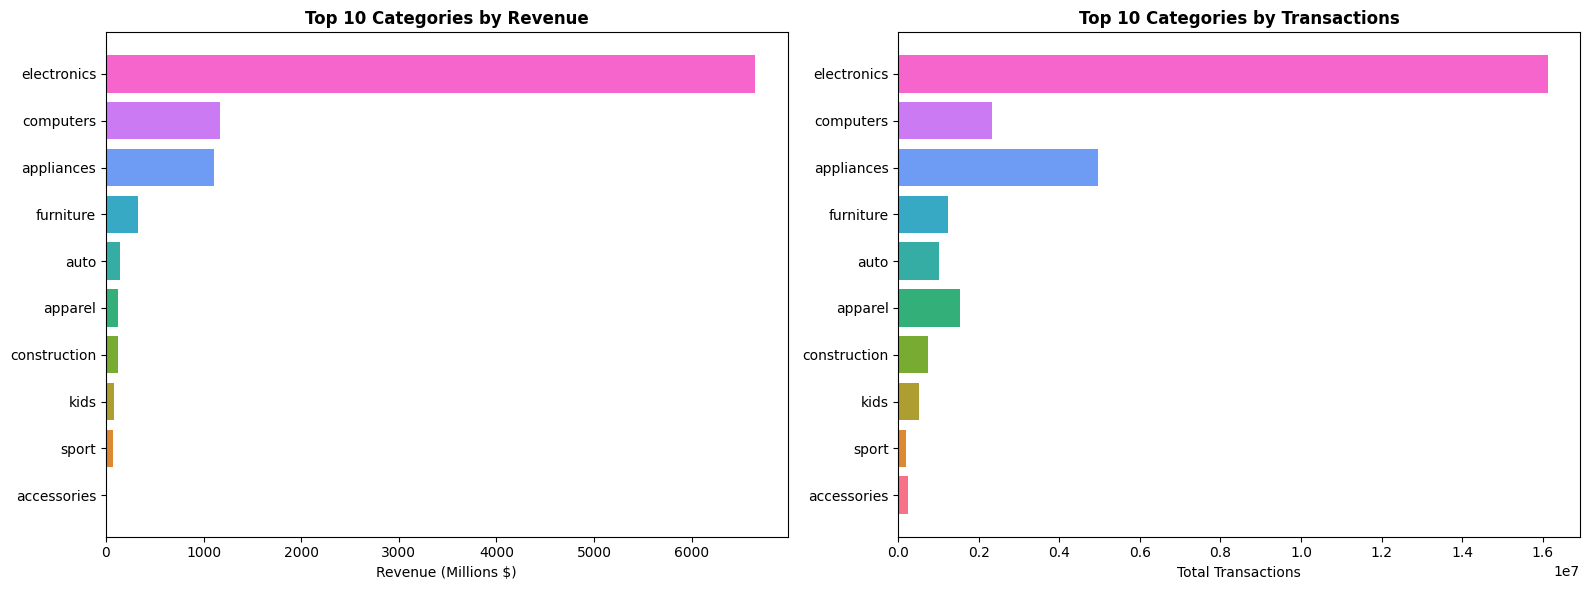


Detail:


,category_l1,total_transactions,total_revenue,revenue_millions,avg_price,unique_buyers
0,electronics,16124905,6.650689e+09,6650.69,412.45,1683255
1,computers,2321338,1.172065e+09,1172.07,504.91,248546
2,appliances,4963333,1.110052e+09,1110.05,223.65,544229
3,furniture,1242152,3.319091e+08,331.91,267.20,202327
4,auto,1012448,1.427750e+08,142.77,141.02,159118
5,apparel,1537393,1.258880e+08,125.89,81.88,258643
6,construction,730055,1.200512e+08,120.05,164.44,101810
7,kids,519821,8.360265e+07,83.60,160.83,99994
8,sport,176262,6.837583e+07,68.38,387.92,40146
9,accessories,237416,1.450885e+07,14.51,61.11,50680


In [8]:
cat_revenue = con.execute("""
    SELECT
        category_l1,
        COUNT(*)                            AS total_transactions,
        ROUND(SUM(price), 2)                AS total_revenue,
        ROUND(SUM(price) / 1000000, 2)      AS revenue_millions,
        ROUND(AVG(price), 2)                AS avg_price,
        COUNT(DISTINCT user_id)             AS unique_buyers
    FROM ecommerce_clean
    WHERE category_l1 != 'uncategorized'
    GROUP BY category_l1
    ORDER BY total_revenue DESC
    LIMIT 10
""").df()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Revenue
axes[0].barh(cat_revenue['category_l1'][::-1],
             cat_revenue['total_revenue'][::-1] / 1e6,
             color=sns.color_palette('husl', 10))
axes[0].set_xlabel('Revenue (Millions $)')
axes[0].set_title('Top 10 Categories by Revenue', fontweight='bold')

# Chart 2 — Transactions
axes[1].barh(cat_revenue['category_l1'][::-1],
             cat_revenue['total_transactions'][::-1],
             color=sns.color_palette('husl', 10))
axes[1].set_xlabel('Total Transactions')
axes[1].set_title('Top 10 Categories by Transactions', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/01_category_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDetail:")
display(cat_revenue)

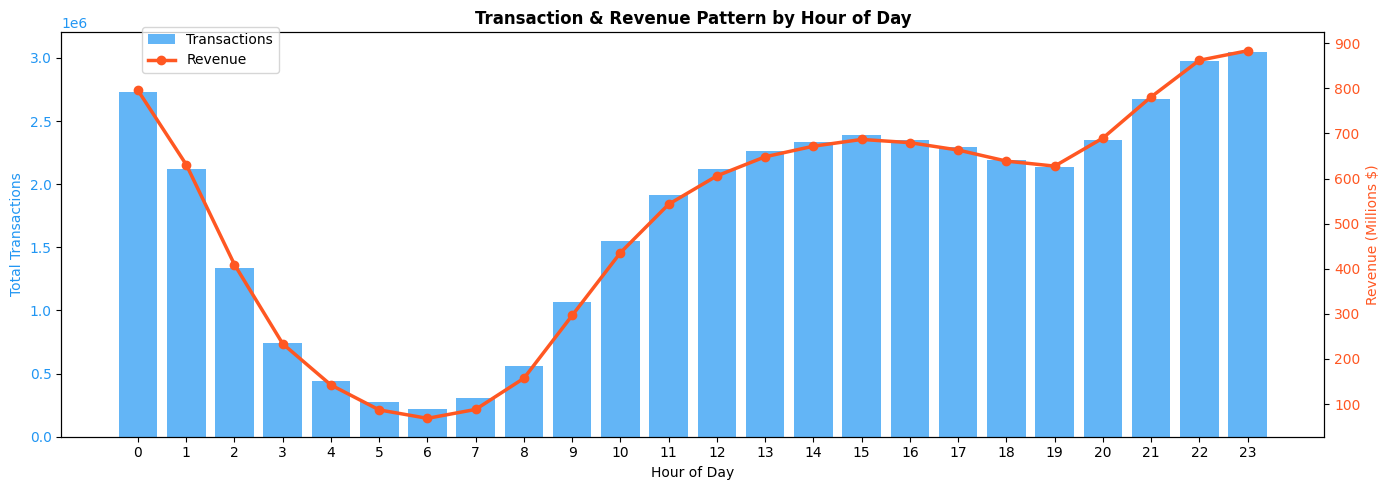

In [4]:
hourly = con.execute("""
    SELECT
        hour_of_day,
        COUNT(*)                AS total_transactions,
        ROUND(SUM(price), 2)    AS total_revenue
    FROM ecommerce_clean
    GROUP BY hour_of_day
    ORDER BY hour_of_day
""").df()

fig, ax1 = plt.subplots(figsize=(14, 5))

# Transactions
color1 = '#2196F3'
ax1.bar(hourly['hour_of_day'], hourly['total_transactions'],
        color=color1, alpha=0.7, label='Transactions')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Total Transactions', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(0, 24))

# Revenue overlay
ax2 = ax1.twinx()
color2 = '#FF5722'
ax2.plot(hourly['hour_of_day'], hourly['total_revenue'] / 1e6,
         color=color2, linewidth=2.5, marker='o', label='Revenue')
ax2.set_ylabel('Revenue (Millions $)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Transaction & Revenue Pattern by Hour of Day', fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.savefig('../reports/figures/02_hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

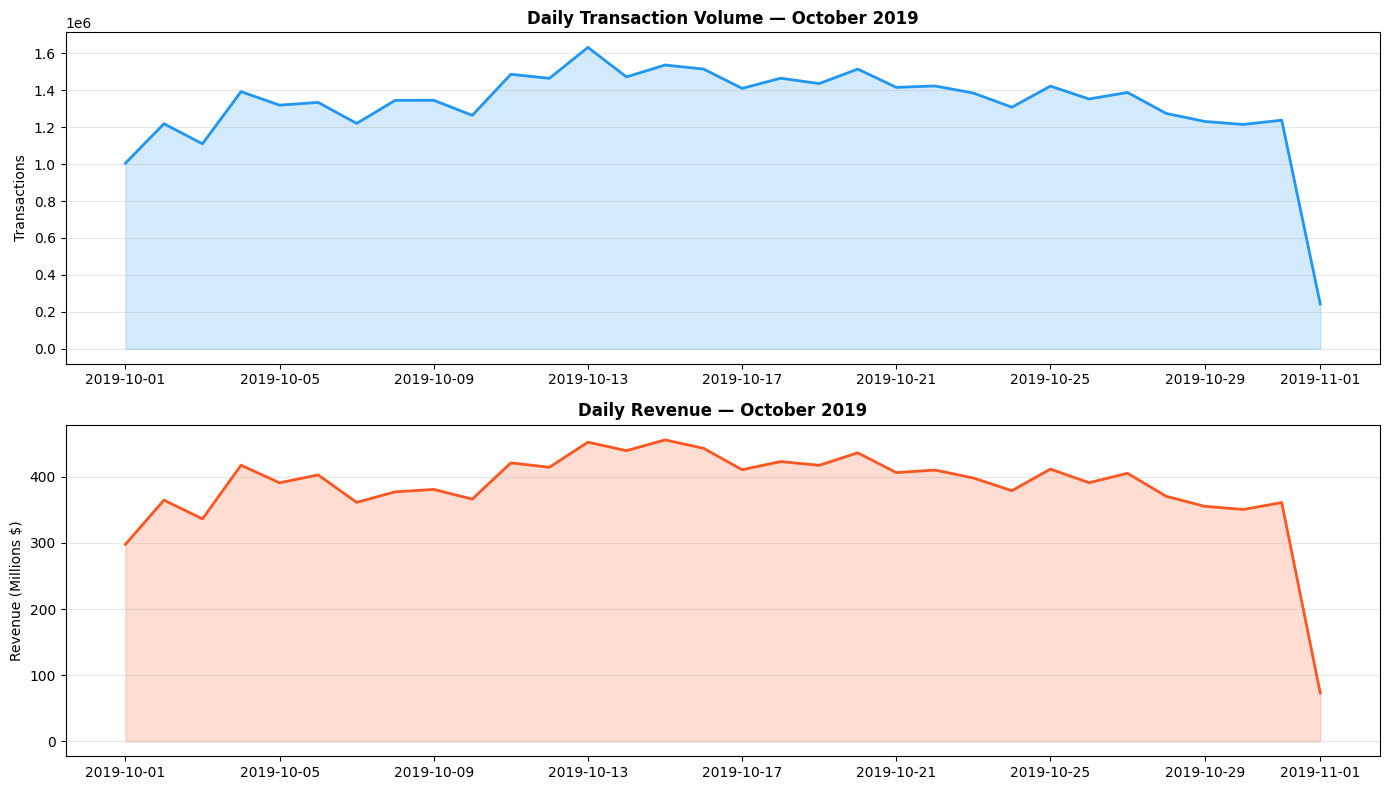

In [5]:
daily = con.execute("""
    SELECT
        event_date,
        COUNT(*)                AS total_transactions,
        COUNT(DISTINCT user_id) AS unique_users,
        ROUND(SUM(price), 2)    AS total_revenue
    FROM ecommerce_clean
    GROUP BY event_date
    ORDER BY event_date
""").df()

daily['event_date'] = pd.to_datetime(daily['event_date'])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Transactions
axes[0].plot(daily['event_date'], daily['total_transactions'],
             color='#2196F3', linewidth=2)
axes[0].fill_between(daily['event_date'], daily['total_transactions'],
                     alpha=0.2, color='#2196F3')
axes[0].set_title('Daily Transaction Volume — October 2019', fontweight='bold')
axes[0].set_ylabel('Transactions')
axes[0].grid(axis='y', alpha=0.3)

# Revenue
axes[1].plot(daily['event_date'], daily['total_revenue'] / 1e6,
             color='#FF5722', linewidth=2)
axes[1].fill_between(daily['event_date'], daily['total_revenue'] / 1e6,
                     alpha=0.2, color='#FF5722')
axes[1].set_title('Daily Revenue — October 2019', fontweight='bold')
axes[1].set_ylabel('Revenue (Millions $)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/03_daily_trend.png', dpi=150, bbox_inches='tight')
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

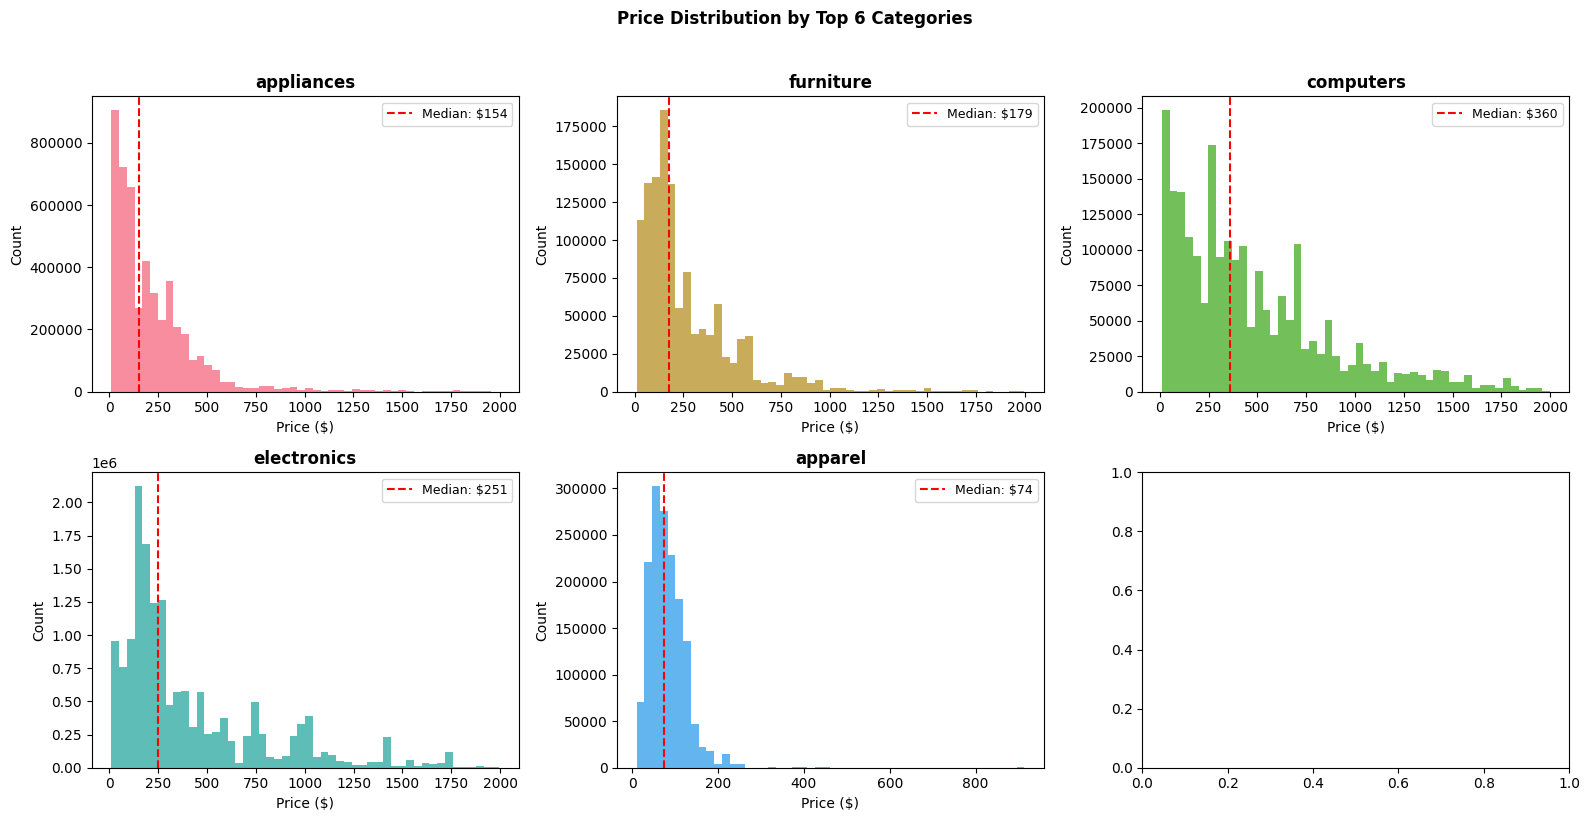

In [6]:
price_dist = con.execute("""
    SELECT category_l1, price
    FROM ecommerce_clean
    WHERE category_l1 != 'uncategorized'
      AND price BETWEEN 10 AND 2000
      AND category_l1 IN (
          SELECT category_l1
          FROM ecommerce_clean
          GROUP BY category_l1
          ORDER BY COUNT(*) DESC
          LIMIT 6
      )
""").df()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

categories = price_dist['category_l1'].unique()

for i, cat in enumerate(categories):
    data = price_dist[price_dist['category_l1'] == cat]['price']
    axes[i].hist(data, bins=50, color=sns.color_palette('husl', 6)[i], alpha=0.8)
    axes[i].set_title(f'{cat}', fontweight='bold')
    axes[i].set_xlabel('Price ($)')
    axes[i].set_ylabel('Count')
    axes[i].axvline(data.median(), color='red',
                    linestyle='--', label=f'Median: ${data.median():.0f}')
    axes[i].legend(fontsize=9)

plt.suptitle('Price Distribution by Top 6 Categories', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/04_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

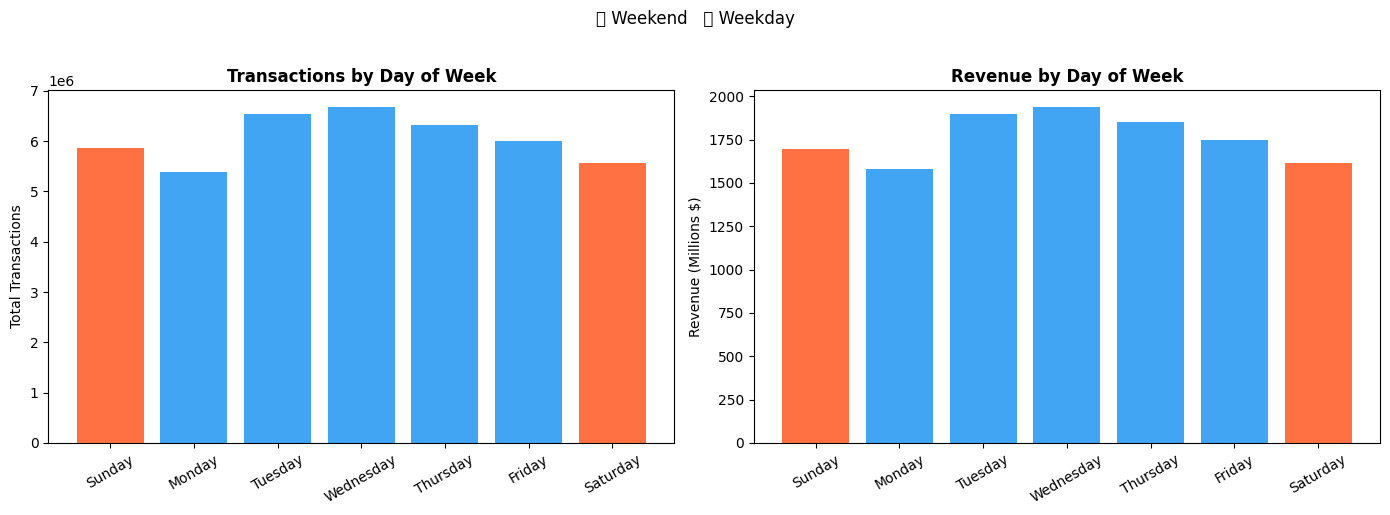

In [7]:
dow = con.execute("""
    SELECT
        day_of_week,
        COUNT(*)                AS total_transactions,
        ROUND(SUM(price), 2)    AS total_revenue
    FROM ecommerce_clean
    GROUP BY day_of_week
    ORDER BY day_of_week
""").df()

day_names = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
dow['day_name'] = dow['day_of_week'].apply(lambda x: day_names[int(x)])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#FF5722' if d in ['Sunday', 'Saturday']
          else '#2196F3' for d in dow['day_name']]

axes[0].bar(dow['day_name'], dow['total_transactions'],
            color=colors, alpha=0.85)
axes[0].set_title('Transactions by Day of Week', fontweight='bold')
axes[0].set_ylabel('Total Transactions')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(dow['day_name'], dow['total_revenue'] / 1e6,
            color=colors, alpha=0.85)
axes[1].set_title('Revenue by Day of Week', fontweight='bold')
axes[1].set_ylabel('Revenue (Millions $)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('🔴 Weekend   🔵 Weekday', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/05_dow_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
con.close()
print("Connection closed")